# Election Data Preparation

* This notebook loads, cleans, and prepares the election and ACS datasets for analysis
* The goal is to create a clean, structured dataset that can be used to examine county-level voting patterns in California
* Overview of the steps

* Use markdown throughout to document what is going on

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/nina_data/countypres_2000-2024.csv")

In [3]:
df.columns

Index(['state', 'county_name', 'year', 'state_po', 'county_fips', 'office',
       'candidate', 'party', 'candidatevotes', 'totalvotes', 'version',
       'mode'],
      dtype='str')

In [4]:
df.head()

,state,county_name,year,state_po,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode
0,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,OTHER,OTHER,293.0,28281,20260225,TOTAL
1,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,CHASE OLIVER,LIBERTARIAN,65.0,28281,20260225,TOTAL
2,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,KAMALA D HARRIS,DEMOCRAT,7439.0,28281,20260225,TOTAL
3,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,DONALD J TRUMP,REPUBLICAN,20484.0,28281,20260225,TOTAL
4,ALABAMA,BALDWIN,2024,AL,1003.0,US PRESIDENT,OTHER,OTHER,1276.0,122249,20260225,TOTAL


In [5]:
df = df[df["state"] == "CALIFORNIA"]
df["state"].unique()

<ArrowStringArray>
['CALIFORNIA']
Length: 1, dtype: str

In [6]:
df = df[df["office"] == "US PRESIDENT"]

In [7]:
df["party"] = df["party"].str.upper()

df["party_simplified"] = df["party"].apply(lambda x: 
    "DEMOCRAT" if x == "DEMOCRAT" else
    "REPUBLICAN" if x == "REPUBLICAN" else
    "OTHER"
)

In [8]:
df["county_name"] = df["county_name"].str.title()

In [9]:
df["county_fips"] = df["county_fips"].astype(int)

In [10]:
df = df.drop(columns=["version", "mode", "state_po"])

In [11]:
df.isnull().sum()

state               0
county_name         0
year                0
county_fips         0
office              0
candidate           0
party               0
candidatevotes      0
totalvotes          0
party_simplified    0
dtype: int64

In [12]:
df["vote_share"] = df["candidatevotes"] / df["totalvotes"]

In [13]:
df.head()

,state,county_name,year,county_fips,office,candidate,party,candidatevotes,totalvotes,party_simplified,vote_share
2298,CALIFORNIA,Alameda,2024,6001,US PRESIDENT,KAMALA D HARRIS,DEMOCRAT,499551.0,669907,DEMOCRAT,0.745702
2299,CALIFORNIA,Alameda,2024,6001,US PRESIDENT,DONALD J TRUMP,REPUBLICAN,140789.0,669907,REPUBLICAN,0.210162
2300,CALIFORNIA,Alameda,2024,6001,US PRESIDENT,OTHER,OTHER,27043.0,669907,OTHER,0.040368
2301,CALIFORNIA,Alameda,2024,6001,US PRESIDENT,CHASE OLIVER,LIBERTARIAN,2524.0,669907,OTHER,0.003768
2302,CALIFORNIA,Alpine,2024,6003,US PRESIDENT,OTHER,OTHER,14.0,738,OTHER,0.018970


In [14]:
dem = df[df["party_simplified"] == "DEMOCRAT"]
rep = df[df["party_simplified"] == "REPUBLICAN"]

In [15]:
merged = pd.merge(
    dem,
    rep,
    on=["county_name", "year"],
    suffixes=("_dem", "_rep")
)

In [16]:
merged = pd.merge(
    dem,
    rep,
    on=["county_name", "year", "county_fips"],
    suffixes=("_dem", "_rep")
)

In [17]:
merged["dem_share"] = merged["vote_share_dem"]
merged["rep_share"] = merged["vote_share_rep"]

In [18]:
merged["margin"] = merged["rep_share"] - merged["dem_share"]

In [19]:
merged["winner"] = merged["margin"].apply(
    lambda x: "Republican" if x > 0 else "Democrat"
)

In [20]:
final_df = merged[[
    "county_name",
    "county_fips",
    "year",
    "dem_share",
    "rep_share",
    "margin",
    "winner"
]]

In [21]:
final_df.head()

,county_name,county_fips,year,dem_share,rep_share,margin,winner
0,Alameda,6001,2024,0.745702,0.210162,-0.535540,Democrat
1,Alpine,6003,2024,0.649051,0.329268,-0.319783,Democrat
2,Amador,6005,2024,0.347409,0.625720,0.278311,Republican
3,Butte,6007,2024,0.467744,0.498953,0.031209,Republican
4,Calaveras,6009,2024,0.346715,0.627832,0.281118,Republican


In [22]:
final_df.to_csv("california_county_voting_cleaned.csv", index=False)

In [23]:
import os
os.listdir()

['.ipynb_checkpoints',
 'ACS Data Analysis.ipynb',
 'CA_counties_mapping.ipynb',
 'california_county_voting_cleaned.csv',
 'election_dataset.ipynb',
 'general_election_data_exploration.ipynb',
 'README.md']

In [36]:
df = pd.read_csv("california_county_voting_cleaned.csv")

In [38]:
import os
print(os.getcwd())

/Commjhub/jupyterhub/home/ninalawson-lab/GROUP1_comm3180_S26_Data_Project/data_analysis


In [41]:
raw_df = pd.read_csv("../data/nina_data/countypres_2000-2024.csv")
clean_df = final_df
clean_df

,county_name,county_fips,year,dem_share,rep_share,margin,winner
0,Alameda,6001,2024,0.745702,0.210162,-0.535540,Democrat
1,Alpine,6003,2024,0.649051,0.329268,-0.319783,Democrat
2,Amador,6005,2024,0.347409,0.625720,0.278311,Republican
3,Butte,6007,2024,0.467744,0.498953,0.031209,Republican
4,Calaveras,6009,2024,0.346715,0.627832,0.281118,Republican
...,...,...,...,...,...,...,...
401,Tulare,6107,2020,0.450046,0.528161,0.078116,Republican
402,Tuolumne,6109,2020,0.393909,0.581722,0.187812,Republican
403,Ventura,6111,2020,0.594544,0.383627,-0.210917,Democrat
404,Yolo,6113,2020,0.694781,0.280511,-0.414270,Democrat


In [42]:
clean_df[clean_df["county_name"] == "Marin"].sort_values("year")

,county_name,county_fips,year,dem_share,rep_share,margin,winner
78,Marin,6041,2000,0.642564,0.283155,-0.359409,Democrat
136,Marin,6041,2004,0.734292,0.254805,-0.479488,Democrat
194,Marin,6041,2008,0.779760,0.202458,-0.577302,Democrat
252,Marin,6041,2012,0.742633,0.229564,-0.513069,Democrat
310,Marin,6041,2016,0.780532,0.156319,-0.624213,Democrat
368,Marin,6041,2020,0.823256,0.157941,-0.665315,Democrat
20,Marin,6041,2024,0.805979,0.166911,-0.639068,Democrat


In [43]:
clean_df[clean_df["county_name"] == "San Francisco"].sort_values("year")

,county_name,county_fips,year,dem_share,rep_share,margin,winner
95,San Francisco,6075,2000,0.755436,0.161033,-0.594404,Democrat
153,San Francisco,6075,2004,0.833796,0.152713,-0.681082,Democrat
211,San Francisco,6075,2008,0.841602,0.136581,-0.705021,Democrat
269,San Francisco,6075,2012,0.835314,0.130329,-0.704985,Democrat
327,San Francisco,6075,2016,0.850396,0.092875,-0.757521,Democrat
385,San Francisco,6075,2020,0.852561,0.127193,-0.725368,Democrat
37,San Francisco,6075,2024,0.803345,0.155334,-0.648011,Democrat


In [44]:
clean_df[clean_df["county_name"] == "Los Angeles"].sort_values("year")

,county_name,county_fips,year,dem_share,rep_share,margin,winner
76,Los Angeles,6037,2000,0.634659,0.323518,-0.311142,Democrat
134,Los Angeles,6037,2004,0.631356,0.356172,-0.275185,Democrat
192,Los Angeles,6037,2008,0.691887,0.288232,-0.403655,Democrat
250,Los Angeles,6037,2012,0.696905,0.278313,-0.418592,Democrat
308,Los Angeles,6037,2016,0.717572,0.224133,-0.493439,Democrat
366,Los Angeles,6037,2020,0.710278,0.268629,-0.441650,Democrat
18,Los Angeles,6037,2024,0.648292,0.319132,-0.329159,Democrat


In [45]:
clean_df[clean_df["county_name"] == "Orange"].sort_values("year")

,county_name,county_fips,year,dem_share,rep_share,margin,winner
87,Orange,6059,2000,0.403561,0.557520,0.153959,Republican
145,Orange,6059,2004,0.390609,0.598001,0.207392,Republican
203,Orange,6059,2008,0.476349,0.501925,0.025575,Republican
261,Orange,6059,2012,0.456450,0.518706,0.062255,Republican
319,Orange,6059,2016,0.509353,0.423498,-0.085855,Democrat
377,Orange,6059,2020,0.534789,0.444447,-0.090342,Democrat
29,Orange,6059,2024,0.497303,0.470763,-0.026540,Democrat


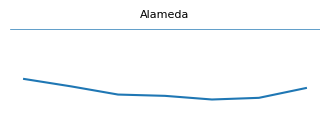

In [46]:
import matplotlib.pyplot as plt

county = "Alameda"  # try any

data = clean_df[clean_df['county_name'] == county].sort_values('year')

plt.figure(figsize=(4,1))
plt.plot(data['year'], data['margin'])

plt.axhline(0, linewidth=0.5)  # neutral line
plt.axis('off')

plt.title(county, fontsize=8)
plt.show()

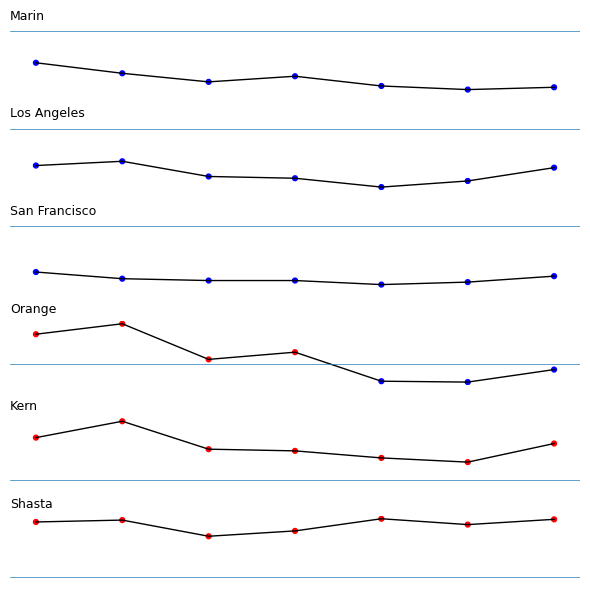

In [48]:
import matplotlib.pyplot as plt

# counties you want
counties = [
    "Marin",
    "Los Angeles",
    "San Francisco",
    "Orange",
    "Kern",
    "Shasta"   # fix spelling here
]

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 6))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # color points based on margin
    colors = ['red' if m > 0 else 'blue' for m in data['margin']]
    
    axes[i].plot(data['year'], data['margin'], color='black', linewidth=1)
    axes[i].scatter(data['year'], data['margin'], c=colors, s=12)
    
    axes[i].axhline(0, linewidth=0.5)  # neutral line
    
    axes[i].set_title(county, fontsize=9, loc='left')
    
    # remove everything for sparkline look
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

In [51]:
clean_df['competitiveness'] = clean_df['margin'].abs()

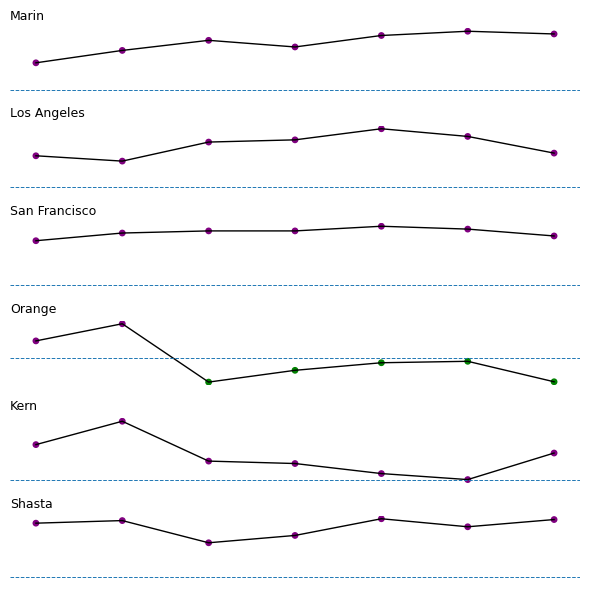

In [55]:
import matplotlib.pyplot as plt

counties = [
    "Marin",
    "Los Angeles",
    "San Francisco",
    "Orange",
    "Kern",
    "Shasta"
]

# make sure this exists
clean_df['competitiveness'] = clean_df['margin'].abs()

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 6))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # COLOR LOGIC
    colors = ['green' if c < 0.1 else 'purple' for c in data['competitiveness']]
    
    axes[i].plot(data['year'], data['competitiveness'], color='black', linewidth=1)
    axes[i].scatter(data['year'], data['competitiveness'], c=colors, s=15)
    
    # threshold line (very helpful visually)
    axes[i].axhline(0.1, linestyle='--', linewidth=0.7)
    
    axes[i].set_title(county, fontsize=9, loc='left')
    
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

This plot shows that most counties in California are consistently non-competitive, with large and stable margins of victory. However, counties like Orange show periods where competitiveness increases, reflecting shifting political dynamics in suburban areas.

In [57]:
import geopandas as gpd

ca_counties = gpd.read_file(
    "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/california-counties.geojson"
)

In [58]:
df_2020 = clean_df[clean_df['year'] == 2020].copy()

# match names
df_2020['county_name'] = df_2020['county_name'].str.upper()
ca_counties['name'] = ca_counties['name'].str.upper()

In [59]:
merged = ca_counties.merge(
    df_2020,
    left_on='name',
    right_on='county_name'
)

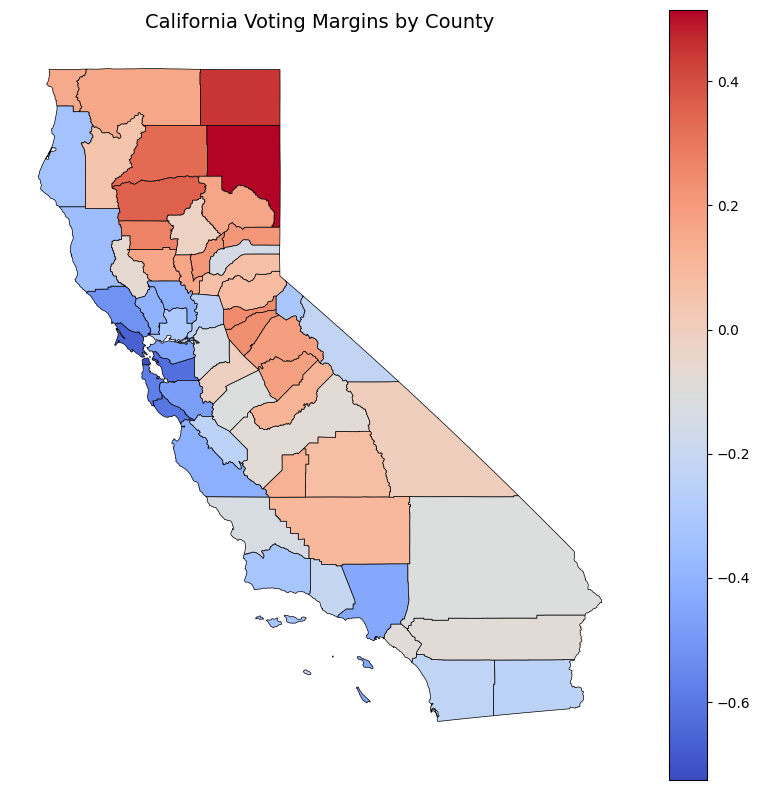

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column='margin',          # what you're visualizing
    cmap='coolwarm',          # same type of gradient your prof uses
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title("California Voting Margins by County", fontsize=14)
ax.axis('off')

plt.show()

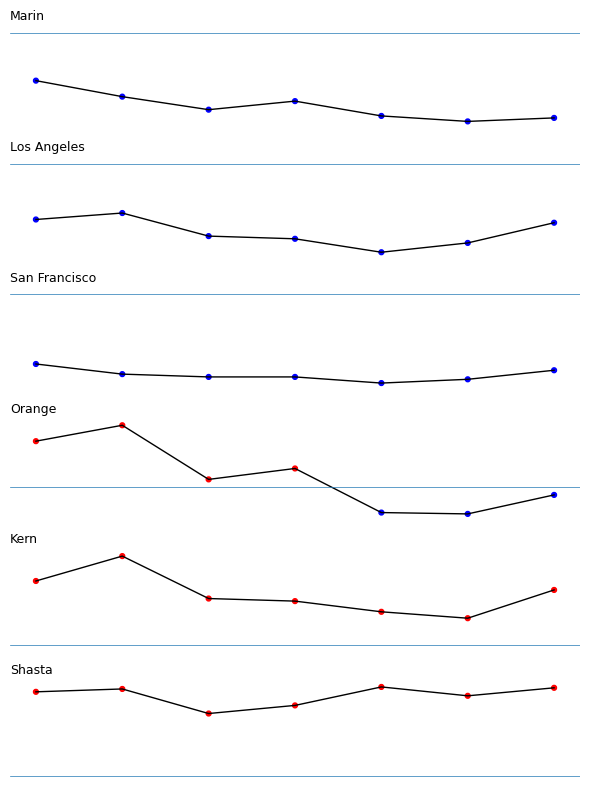

In [61]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 8))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # red = rep, blue = dem
    colors = ['red' if m > 0 else 'blue' for m in data['margin']]
    
    axes[i].plot(data['year'], data['margin'], color='black', linewidth=1)
    axes[i].scatter(data['year'], data['margin'], c=colors, s=12)
    
    axes[i].axhline(0, linewidth=0.5)
    axes[i].set_title(county, fontsize=9, loc='left')
    
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

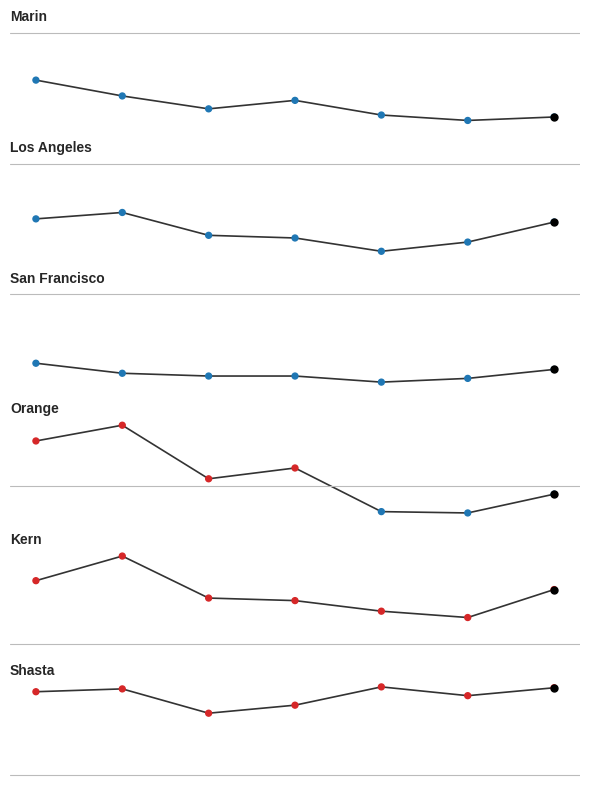

In [63]:
import matplotlib.pyplot as plt

# nicer overall style
plt.style.use('seaborn-v0_8-white')

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 8))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # softer colors
    colors = ['#d62728' if m > 0 else '#1f77b4' for m in data['margin']]
    
    axes[i].plot(data['year'], data['margin'], color='#333333', linewidth=1.2)
    axes[i].scatter(data['year'], data['margin'], c=colors, s=18, zorder=3)
    
    # subtle zero line
    axes[i].axhline(0, color='#bbbbbb', linewidth=0.8)
    
    # highlight LAST point (this is a big visual improvement)
    axes[i].scatter(
        data['year'].iloc[-1],
        data['margin'].iloc[-1],
        color='black',
        s=25,
        zorder=4
    )
    
    axes[i].set_title(county, fontsize=10, loc='left', fontweight='bold')
    
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

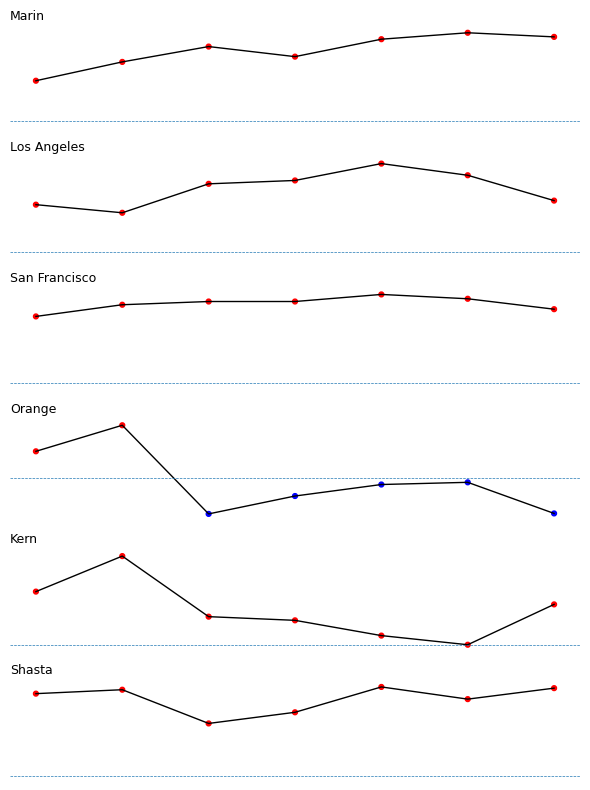

In [62]:
# create competitiveness if not already
clean_df['competitiveness'] = clean_df['margin'].abs()

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 8))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # blue = competitive, red = not competitive
    colors = ['blue' if c < 0.1 else 'red' for c in data['competitiveness']]
    
    axes[i].plot(data['year'], data['competitiveness'], color='black', linewidth=1)
    axes[i].scatter(data['year'], data['competitiveness'], c=colors, s=12)
    
    axes[i].axhline(0.1, linestyle='--', linewidth=0.5)
    axes[i].set_title(county, fontsize=9, loc='left')
    
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

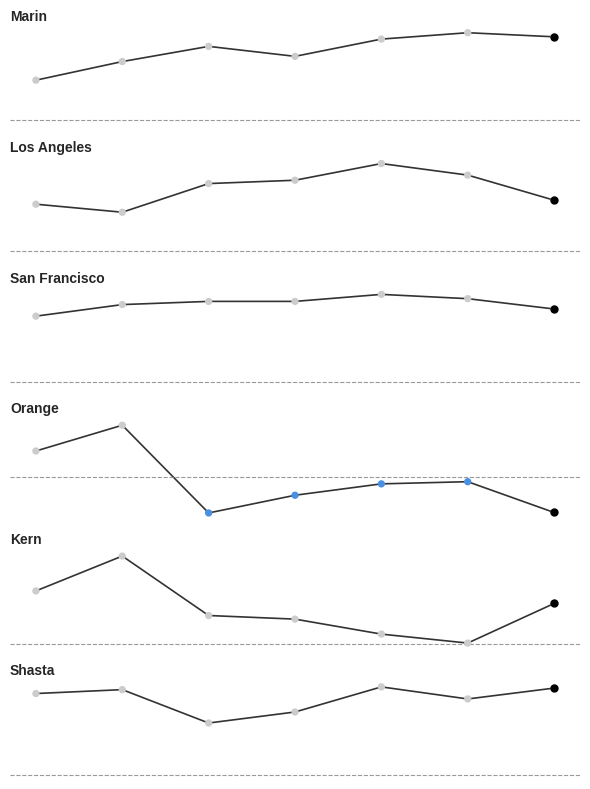

In [65]:
import matplotlib.pyplot as plt

# make sure this exists
clean_df['competitiveness'] = clean_df['margin'].abs()

plt.style.use('seaborn-v0_8-white')

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 8))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # color logic:
    # blue = competitive (close)
    # light gray = not competitive
    colors = ['#4a90e2' if c < 0.1 else '#cccccc' for c in data['competitiveness']]
    
    # line
    axes[i].plot(
        data['year'],
        data['competitiveness'],
        color='#333333',
        linewidth=1.2
    )
    
    # points
    axes[i].scatter(
        data['year'],
        data['competitiveness'],
        c=colors,
        s=18,
        zorder=3
    )
    
    # threshold line (VERY important visually)
    axes[i].axhline(
        0.1,
        linestyle='--',
        color='#999999',
        linewidth=0.8
    )
    
    # highlight last point
    axes[i].scatter(
        data['year'].iloc[-1],
        data['competitiveness'].iloc[-1],
        color='black',
        s=25,
        zorder=4
    )
    
    # title
    axes[i].set_title(
        county,
        fontsize=10,
        loc='left',
        fontweight='bold'
    )
    
    # remove clutter
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

axes[i].fill_between(
    data['year'],
    data['competitiveness'],
    0,
    color='#dddddd',
    alpha=0.2
)

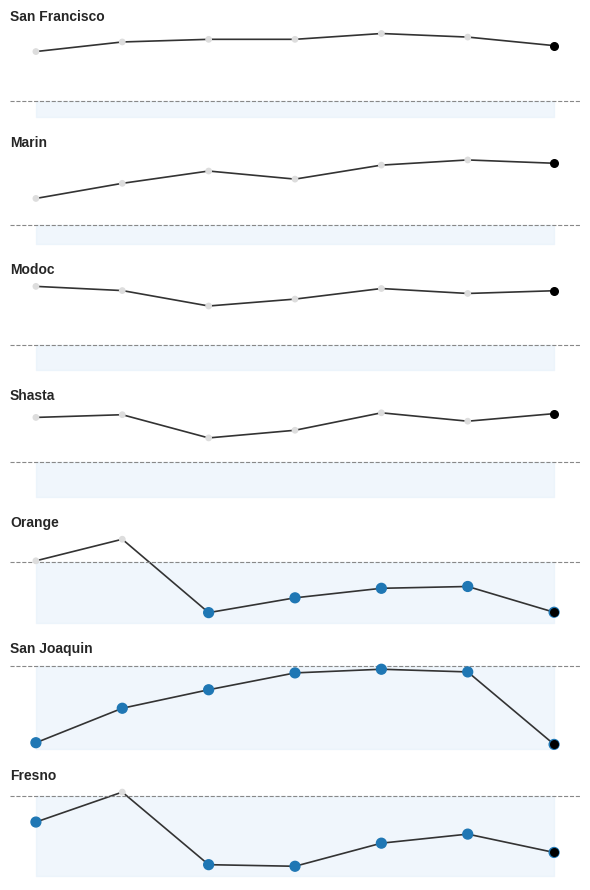

In [66]:
import matplotlib.pyplot as plt

# --- counties ---
counties = [
    "San Francisco", "Marin",          # strong blue
    "Modoc", "Shasta",                # strong red
    "Orange", "San Joaquin", "Fresno" # competitive / interesting
]

# --- create competitiveness ---
clean_df['competitiveness'] = clean_df['margin'].abs()

plt.style.use('seaborn-v0_8-white')

fig, axes = plt.subplots(len(counties), 1, figsize=(6, 9))

for i, county in enumerate(counties):
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # --- color + size logic ---
    colors = [
        '#1f77b4' if c < 0.15 else '#dddddd'
        for c in data['competitiveness']
    ]
    
    sizes = [
        50 if c < 0.15 else 15
        for c in data['competitiveness']
    ]
    
    # --- shaded competitive zone ---
    axes[i].fill_between(
        data['year'],
        0,
        0.15,
        color='#e6f0fa',
        alpha=0.6
    )
    
    # --- line ---
    axes[i].plot(
        data['year'],
        data['competitiveness'],
        color='#333333',
        linewidth=1.2
    )
    
    # --- points ---
    axes[i].scatter(
        data['year'],
        data['competitiveness'],
        c=colors,
        s=sizes,
        zorder=3
    )
    
    # --- threshold line ---
    axes[i].axhline(
        0.15,
        linestyle='--',
        color='#888888',
        linewidth=0.8
    )
    
    # --- highlight last point ---
    axes[i].scatter(
        data['year'].iloc[-1],
        data['competitiveness'].iloc[-1],
        color='black',
        s=30,
        zorder=4
    )
    
    # --- title ---
    axes[i].set_title(
        county,
        fontsize=10,
        loc='left',
        fontweight='bold'
    )
    
    # --- remove clutter ---
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    
    for spine in axes[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

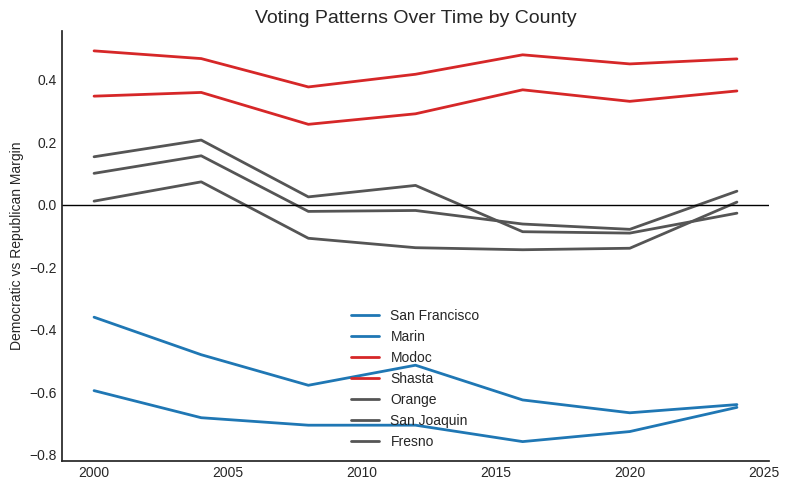

In [67]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-white')

fig, ax = plt.subplots(figsize=(8, 5))

for county in counties:
    
    data = clean_df[clean_df['county_name'] == county].sort_values('year')
    
    # color logic
    if county in ["San Francisco", "Marin"]:
        color = "#1f77b4"  # blue
    elif county in ["Shasta", "Modoc"]:
        color = "#d62728"  # red
    else:
        color = "#555555"  # neutral (mixed counties)
    
    ax.plot(
        data['year'],
        data['margin'],
        label=county,
        linewidth=2,
        color=color
    )

# zero line (important)
ax.axhline(0, color='black', linewidth=1)

# labels
ax.set_title("Voting Patterns Over Time by County", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Democratic vs Republican Margin")

# clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend
ax.legend(frameon=False)

plt.tight_layout()
plt.show()